Load the data from using Pandas library:

In [ ]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')


View only data types:

In [ ]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


Check Summary statistic:

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Check misssing values in each column:

In [ ]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Check unique counts in each column:

In [ ]:
print(df.nunique())

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64


Create Visualization:

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


Bar plots for categorical Variables:

Survived Column:

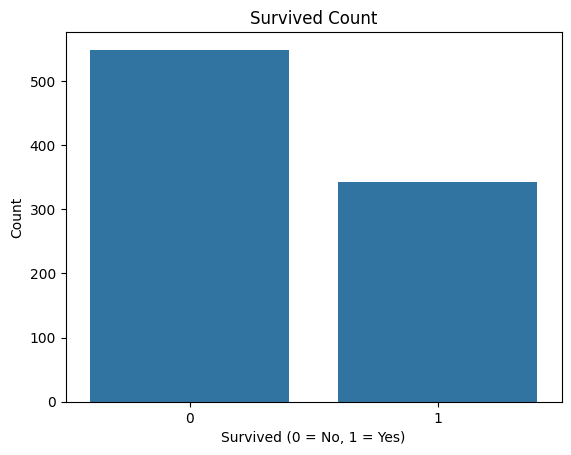

In [ ]:
sns.countplot(x='Survived', data=df)
plt.title('Survived Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

Sex Column:

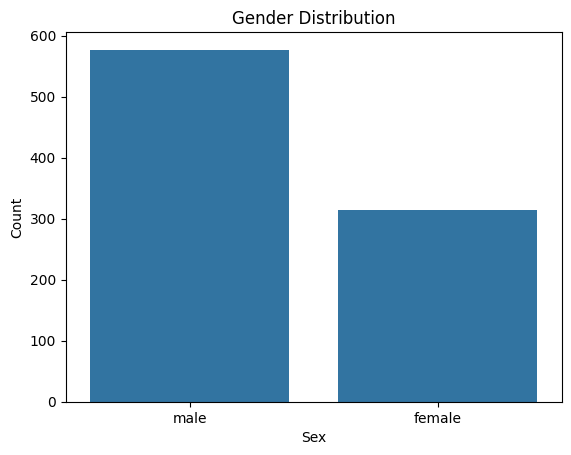

In [ ]:
sns.countplot(x='Sex', data=df)
plt.title('Gender Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

Pclass Column:

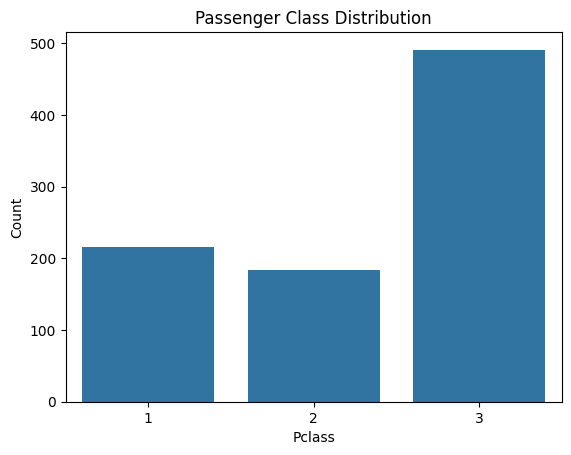

In [ ]:
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Distribution')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.show()

Embarked Column:

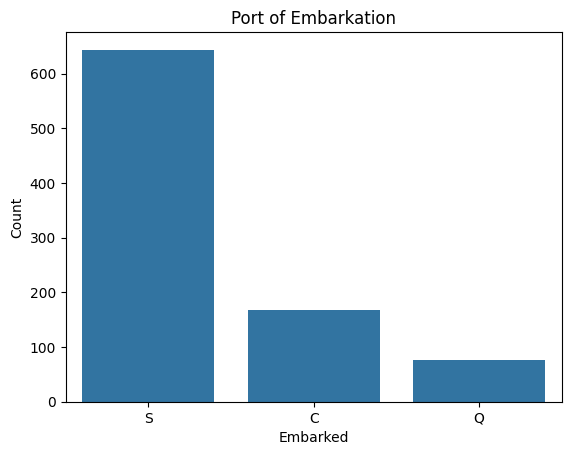

In [ ]:
sns.countplot(x='Embarked', data=df)
plt.title('Port of Embarkation')
plt.xlabel('Embarked')
plt.ylabel('Count')
plt.show()

Scatter plots or Histograms For Numerical varriables:

Age Distribution:

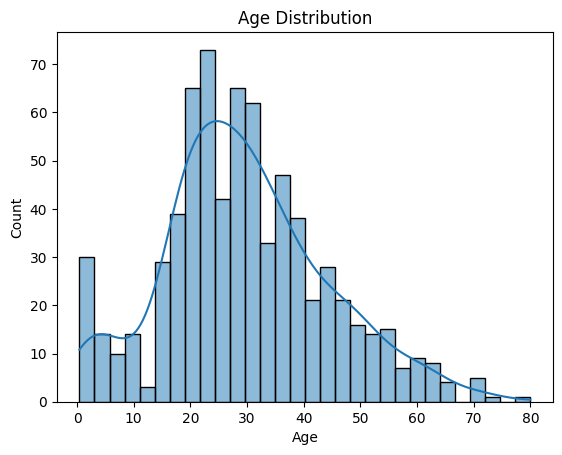

In [ ]:
sns.histplot(df['Age'].dropna(), kde=True, bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Fare Distribution:

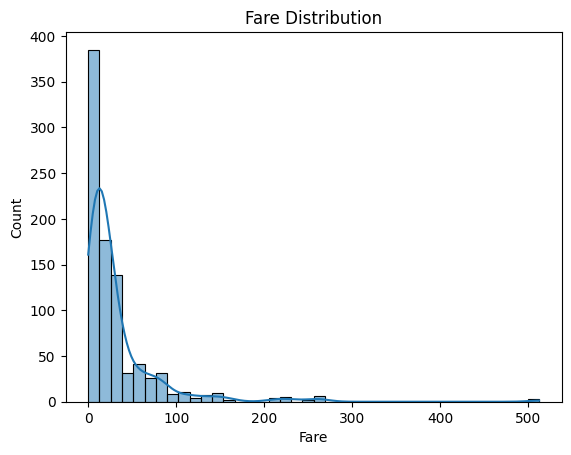

In [ ]:
sns.histplot(df['Fare'], kde=True, bins=40)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

Sibsp Distribution:

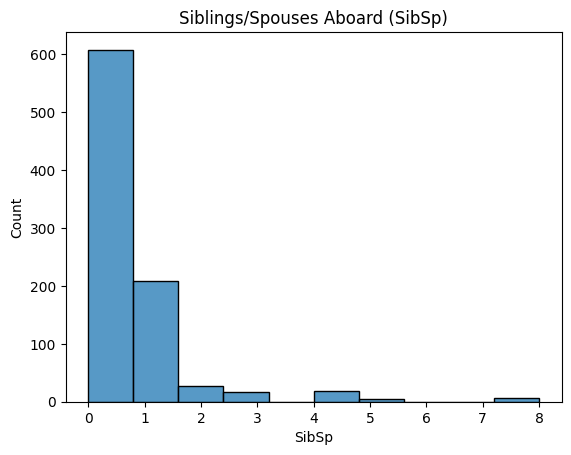

In [ ]:
sns.histplot(df['SibSp'], bins=10)
plt.title('Siblings/Spouses Aboard (SibSp)')
plt.xlabel('SibSp')
plt.ylabel('Count')
plt.show()


Parch Distribution:

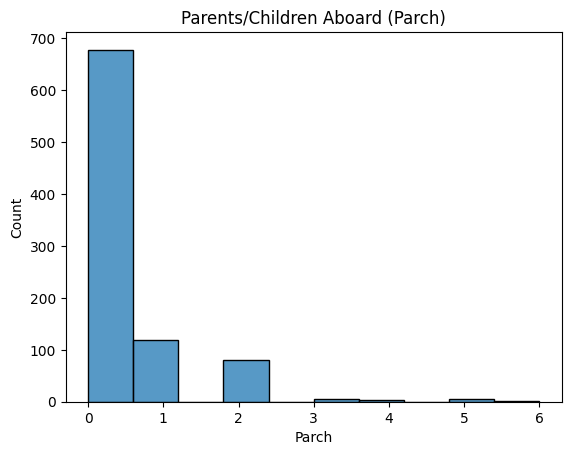

In [ ]:
sns.histplot(df['Parch'], bins=10)
plt.title('Parents/Children Aboard (Parch)')
plt.xlabel('Parch')
plt.ylabel('Count')
plt.show()

Scatter Plots:
Relationship btw Variables:

Age Vs Fare:

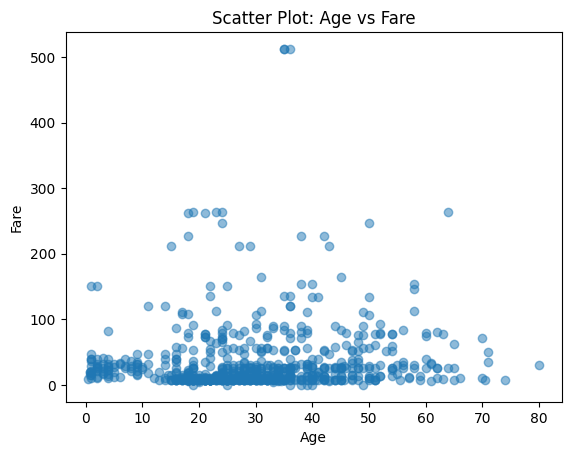

In [ ]:
plt.scatter(df['Age'], df['Fare'], alpha=0.5)
plt.title('Scatter Plot: Age vs Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

Age vs Survived:

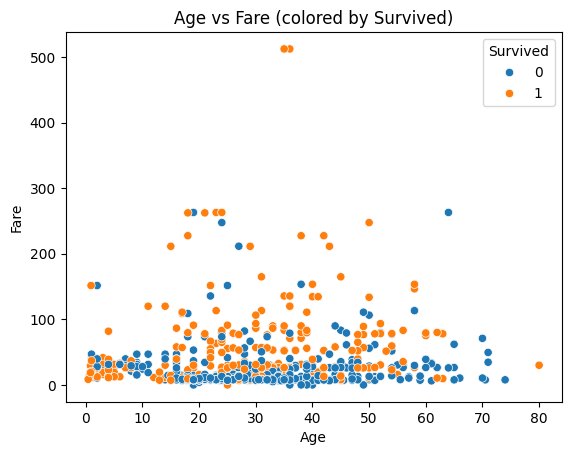

In [ ]:
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title('Age vs Fare (colored by Survived)')
plt.show()

Correlation Heatmap For Numerical Features:

Compute Correlation Matrix:

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

Plot the Heatmap:

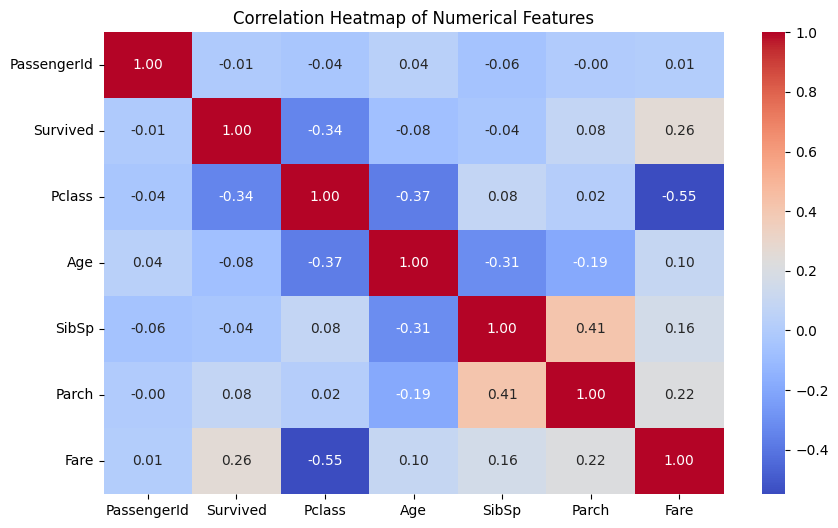

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


Full Code: Task_1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- 1. Loading the Dataset ---")

file_name = 'train.csv'
try:
    df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
    print(f"Dataset '{file_name}' loaded successfully!")
    print("\nFirst 5 rows of the dataset:")
    print(df.head())
except FileNotFoundError:
    print(f"Error: {file_name} not found. Please make sure the file is in the correct directory.")
    print("For Titanic dataset, download 'train.csv' from: https://www.kaggle.com/c/titanic/data")
    print("For Iris dataset, download 'iris.csv' (or similar) from common sources.")
    exit()

print("\n--- 2. Exploring Dataset Features ---")

print("\n2.1. Data Types of each column:")
print(df.info())

print("\n2.2. Summary Statistics for numerical columns:")
print(df.describe())

print("\n2.2. Summary Statistics for categorical columns (including object and category dtypes):")
print(df.describe(include='object'))

print("\n2.3. Number of Missing Values in each column:")
print(df.isnull().sum())

print("\n2.4. Unique Counts and Values for Categorical Columns:")
for column in df.select_dtypes(include=['object', 'int64']).columns:
    if df[column].nunique() < 20:
        print(f"\n--- Column: '{column}' ---")
        print(f"Number of unique values: {df[column].nunique()}")
        print(f"Value Counts:\n{df[column].value_counts()}")


--- 1. Loading the Dataset ---
Dataset 'train.csv' loaded successfully!

First 5 rows of the dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3     

Create Visualization Full Code


--- 3. Creating Visualizations ---

3.1. Generating Bar Plots for Categorical Variables...


<Figure size 1500x1000 with 0 Axes>

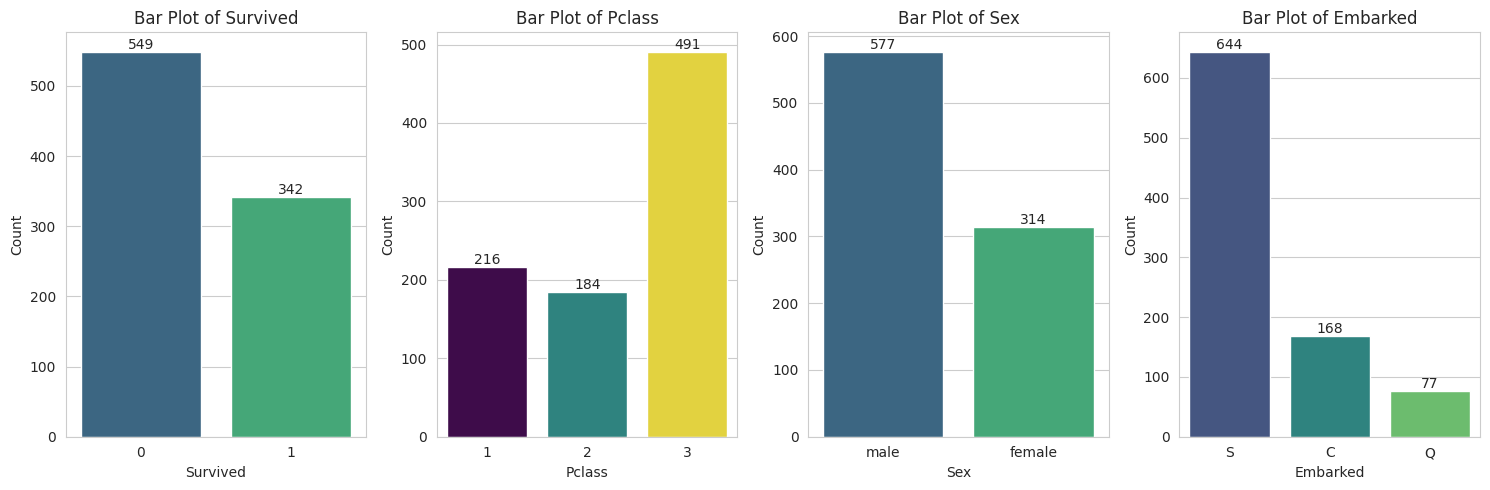


3.2. Generating Histograms for Numerical Variables...


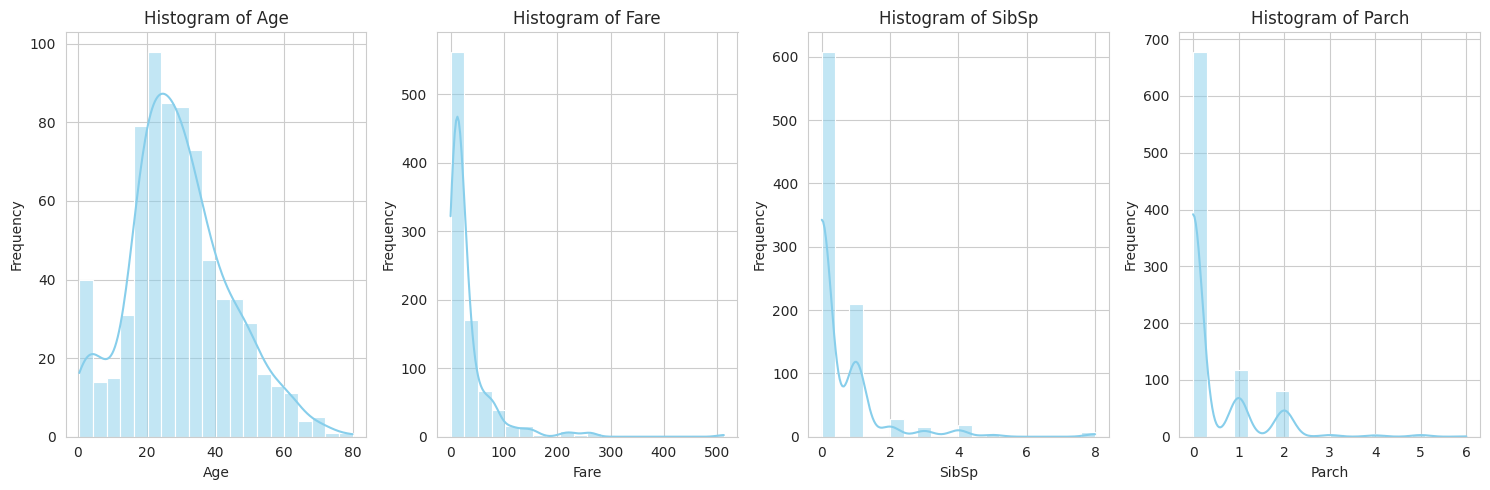


Generating a Scatter Plot (Age vs. Fare)...


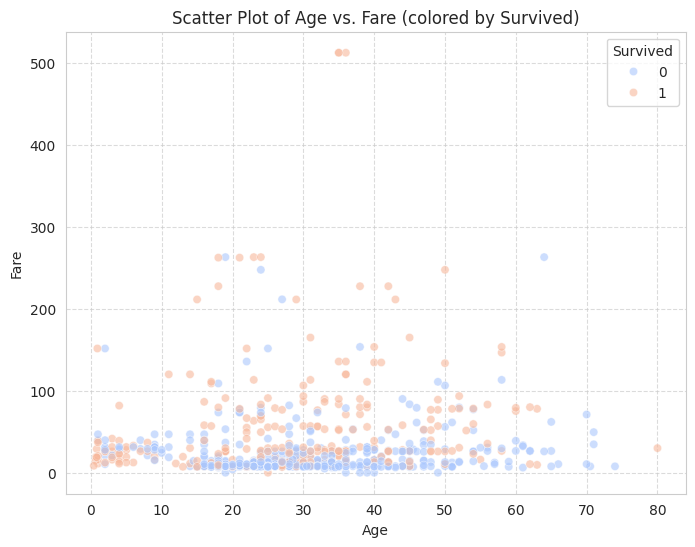


3.3. Generating Correlation Heatmap for Numerical Features...


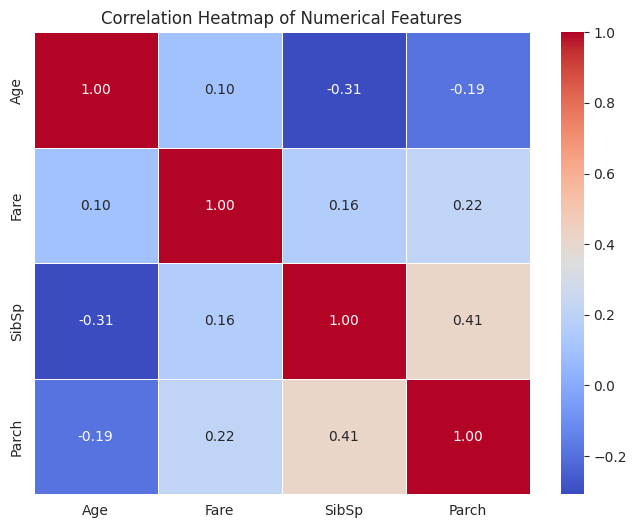


--- Data Exploration and Visualization Complete ---


In [ ]:
print("\n--- 3. Creating Visualizations ---")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_cols = ['Survived', 'Pclass', 'Sex', 'Embarked']

print("\n3.1. Generating Bar Plots for Categorical Variables...")
plt.figure(figsize=(15, 5))

for i, col in enumerate(categorical_cols):
    plt.subplot(1, len(categorical_cols), i + 1)
    sns.countplot(x=col, hue=col, data=df, palette='viridis', legend=False)
    plt.title(f'Bar Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    for container in plt.gca().containers:
        plt.gca().bar_label(container)

plt.tight_layout()
plt.show()


print("\n3.2. Generating Histograms for Numerical Variables...")
plt.figure(figsize=(15, 5))

for i, col in enumerate(numerical_cols):
    plt.subplot(1, len(numerical_cols), i + 1)
    sns.histplot(df[col].dropna(), kde=True, bins=20, color='skyblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\nGenerating a Scatter Plot (Age vs. Fare)...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Fare', data=df, hue='Survived', alpha=0.6, palette='coolwarm')
plt.title('Scatter Plot of Age vs. Fare (colored by Survived)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\n3.3. Generating Correlation Heatmap for Numerical Features...")
plt.figure(figsize=(8, 6))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

print("\n--- Data Exploration and Visualization Complete ---")
